In [2]:
import pandas as pd
from prophet import Prophet
import numpy as np

df = pd.read_csv("MOP 6 - Exercise 7 - KPI Forecasting - Sample KPI report - 30 months.csv")

print("Sample KPI file loaded successfully")
print("Rows:", len(df))
print("Columns:", df.columns.tolist())

df.head()


Sample KPI file loaded successfully
Rows: 3000
Columns: ['Unnamed: 0', 'Date', 'Cluster', 'Cell', 'Traffic_GB']


,Unnamed: 0,Date,Cluster,Cell,Traffic_GB
0,0,31-01-2023,Cluster_1,Cluster_1_Cell_1,170.7
1,1,28-02-2023,Cluster_1,Cluster_1_Cell_1,174.2
2,2,31-03-2023,Cluster_1,Cluster_1_Cell_1,190.9
3,3,30-04-2023,Cluster_1,Cluster_1_Cell_1,214.1
4,4,31-05-2023,Cluster_1,Cluster_1_Cell_1,231.3


In [4]:
# Convert Date column (explicit day-first format)

df["Date"] = pd.to_datetime(
df["Date"],
dayfirst=True,
errors="coerce"
)
df = df.dropna(subset=["Date"])
print("After fixing dates:", len(df))

After fixing dates: 3000


In [5]:
# Remove duplicate Cell–Date records
df = df.sort_values(["Cell", "Date"])
df = df.drop_duplicates(subset=["Cell", "Date"], keep="first")

In [6]:
print("After duplicate Cell-Date removal:", len(df))

After duplicate Cell-Date removal: 3000


In [7]:
# Remove rows with missing values
df = df.dropna(subset=["Date", "Cell", "Traffic_GB"])
print("After removing missing values:", len(df))

After removing missing values: 3000


In [8]:
# Validate KPI value ranges (based on your local rules - telecom sanity)
df = df[df["Traffic_GB"] > 0]
print("After removing non-positive traffic values:", len(df))

After removing non-positive traffic values: 3000


In [9]:
# Sort Data (critical for time series)
df = df.sort_values(["Cell", "Date"])

In [10]:
# Final data quality summary
print("\nFINAL DATA QUALITY SUMMARY")
print("----------------------------")
print("Total rows after validation:", len(df))
print("Number of unique cells:", df["Cell"].nunique())
print("Date range:", df["Date"].min(), "to", df["Date"].max())
df.describe()


FINAL DATA QUALITY SUMMARY
----------------------------
Total rows after validation: 3000
Number of unique cells: 100
Date range: 2023-01-31 00:00:00 to 2025-06-30 00:00:00


,Unnamed: 0,Date,Traffic_GB
count,3000.000000,3000,3000.000000
mean,1499.500000,2024-04-15 03:59:59.999999744,1984.717100
min,0.000000,2023-01-31 00:00:00,132.800000
25%,749.750000,2023-08-31 00:00:00,530.325000
50%,1499.500000,2024-04-15 00:00:00,1232.000000
75%,2249.250000,2024-11-30 00:00:00,2912.725000
max,2999.000000,2025-06-30 00:00:00,14042.700000
std,866.169729,NaN,1916.916847


In [11]:
# Save validated KPI dataset
validated_file = "Validated_KPI_Report_30_Months.csv"
df.to_csv(validated_file, index=False)
print(f"\nValidated KPI file saved as: {validated_file}")


Validated KPI file saved as: Validated_KPI_Report_30_Months.csv


In [12]:
# Reload validated KPI file for downstream steps

df = pd.read_csv(validated_file)
df["Date"] = pd.to_datetime(df["Date"])
print("Validated KPI file reloaded for AI training.")
print("Rows available for modeling:", len(df))

Validated KPI file reloaded for AI training.
Rows available for modeling: 3000


In [13]:
future_months = 6
forecast_rows = []

for cell, cell_df in df.groupby("Cell"):

    prophet_df = cell_df.rename(
        columns={"Date": "ds", "Traffic_GB": "y"}
    )[["ds", "y"]]

    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False
    )

    model.fit(prophet_df)

    future = model.make_future_dataframe(
        periods=future_months,
        freq="ME"
    )

    forecast = model.predict(future)
    future_forecast = forecast.tail(future_months)

    for _, row in future_forecast.iterrows():
        forecast_rows.append({
            "Date": row["ds"],
            "Cell": cell,
            "Forecast_Traffic_GB": round(row["yhat"], 1)
        })


12:06:22 - cmdstanpy - INFO - Chain [1] start processing
12:06:22 - cmdstanpy - INFO - Chain [1] done processing
12:06:22 - cmdstanpy - INFO - Chain [1] start processing
12:07:17 - cmdstanpy - INFO - Chain [1] done processing
12:07:18 - cmdstanpy - INFO - Chain [1] start processing
12:07:18 - cmdstanpy - INFO - Chain [1] done processing
12:07:18 - cmdstanpy - INFO - Chain [1] start processing
12:07:19 - cmdstanpy - INFO - Chain [1] done processing
12:07:19 - cmdstanpy - INFO - Chain [1] start processing
12:07:19 - cmdstanpy - INFO - Chain [1] done processing
12:07:20 - cmdstanpy - INFO - Chain [1] start processing
12:07:20 - cmdstanpy - INFO - Chain [1] done processing
12:07:21 - cmdstanpy - INFO - Chain [1] start processing
12:07:21 - cmdstanpy - INFO - Chain [1] done processing
12:07:21 - cmdstanpy - INFO - Chain [1] start processing
12:07:22 - cmdstanpy - INFO - Chain [1] done processing
12:07:22 - cmdstanpy - INFO - Chain [1] start processing
12:07:22 - cmdstanpy - INFO - Chain [1]

In [14]:
forecast_df = pd.DataFrame(forecast_rows)

forecast_df.head(10)


,Date,Cell,Forecast_Traffic_GB
0,2025-07-31,Cluster_1_Cell_1,3102.4
1,2025-08-31,Cluster_1_Cell_1,3178.8
2,2025-09-30,Cluster_1_Cell_1,3289.1
3,2025-10-31,Cluster_1_Cell_1,3407.6
4,2025-11-30,Cluster_1_Cell_1,3564.8
5,2025-12-31,Cluster_1_Cell_1,3746.7
6,2025-07-31,Cluster_1_Cell_10,5381.7
7,2025-08-31,Cluster_1_Cell_10,5868.3
8,2025-09-30,Cluster_1_Cell_10,6175.2
9,2025-10-31,Cluster_1_Cell_10,6594.6


12:14:24 - cmdstanpy - INFO - Chain [1] start processing
12:14:24 - cmdstanpy - INFO - Chain [1] done processing


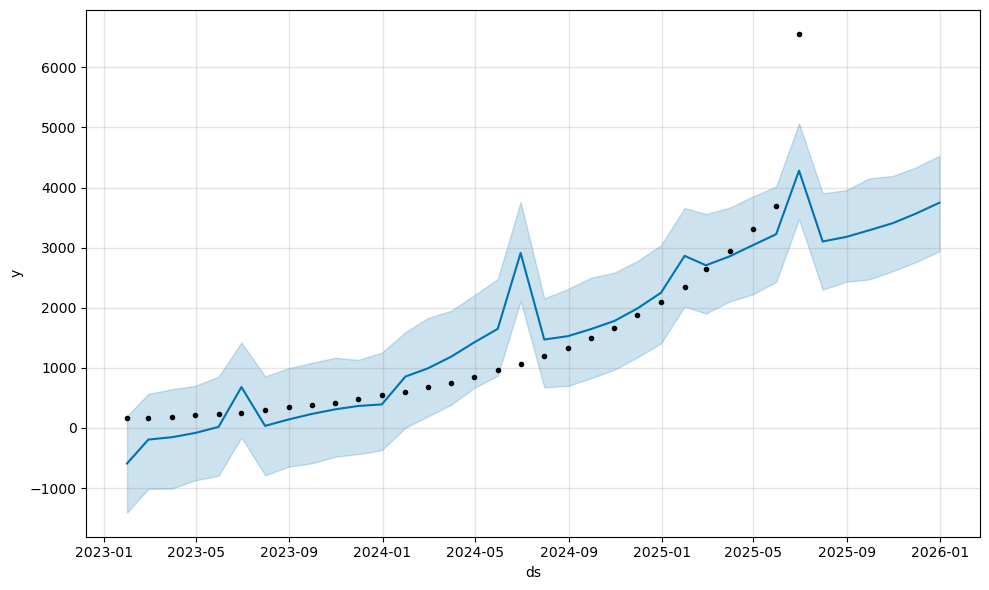

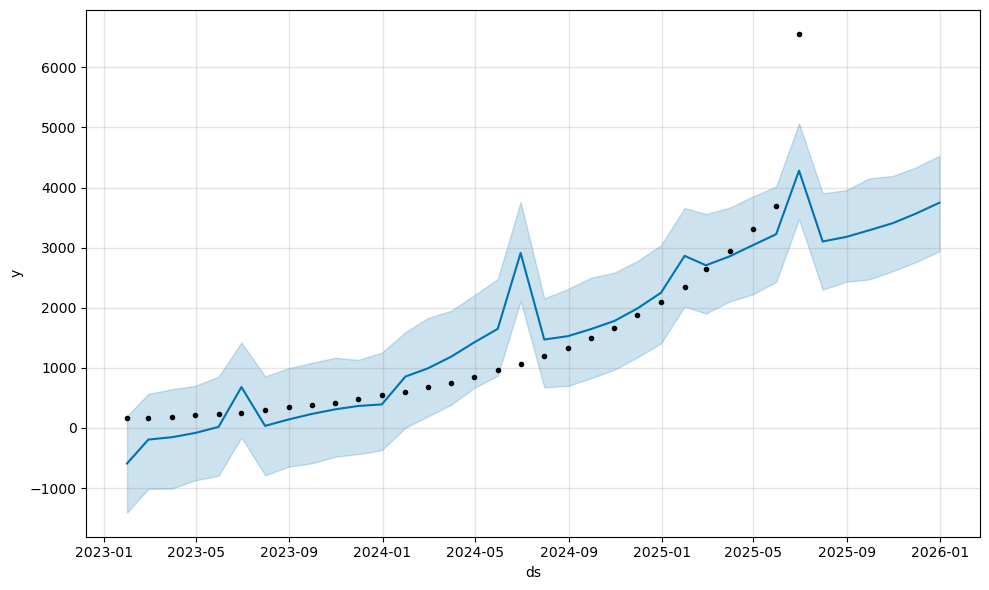

In [15]:
sample_cell = df["Cell"].iloc[0]

cell_df = df[df["Cell"] == sample_cell].rename(
    columns={"Date": "ds", "Traffic_GB": "y"}
)

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model.fit(cell_df)

future = model.make_future_dataframe(periods=6, freq="ME")
forecast = model.predict(future)

model.plot(forecast)


In [16]:
forecast_df.to_csv(
"Traffic_Forecast_Next_6_Months_Per_Cell_Prophet.csv",
index=False
)
print("Forecast KPI report saved successfully")

Forecast KPI report saved successfully
